# Preliminary Steps

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

! kaggle datasets download kanths028/usa-housing

Dataset URL: https://www.kaggle.com/datasets/kanths028/usa-housing
License(s): unknown
100%|█████████████████████████████████████████| 363k/363k [00:00<00:00, 118MB/s]



In [3]:
! unzip usa-housing.zip

Archive:  usa-housing.zip
  inflating: USA_Housing.csv         


Read in your data!

In [3]:
housing = pd.read_csv("USA_Housing.csv")
housing

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


# EDA

The ultimate end goal for this regression is to accurately predict the price of a house depending on the variables we use. First, let's understand the data.

In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [5]:
housing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [7]:
housing.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

Do anything else you think might be useful below for your EDA/understanding of the data!

# Visualizations

Create at least 3 visualizations (scatter plot, bar plot, histogram, box plot, etc.) that helps you understand the relationship between variables below.

Text(0, 0.5, 'Price')

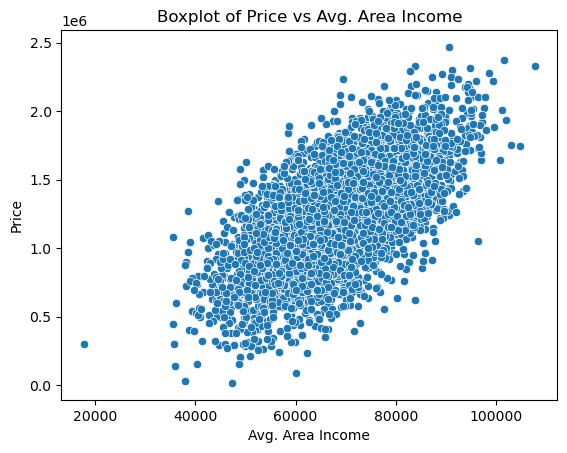

In [6]:
# Visualization 1
sns.scatterplot(data=housing,x="Avg. Area Income",y="Price")
plt.title("Boxplot of Price vs Avg. Area Income")
plt.xlabel("Avg. Area Income")
plt.ylabel("Price")


Text(0, 0.5, 'Frequency')

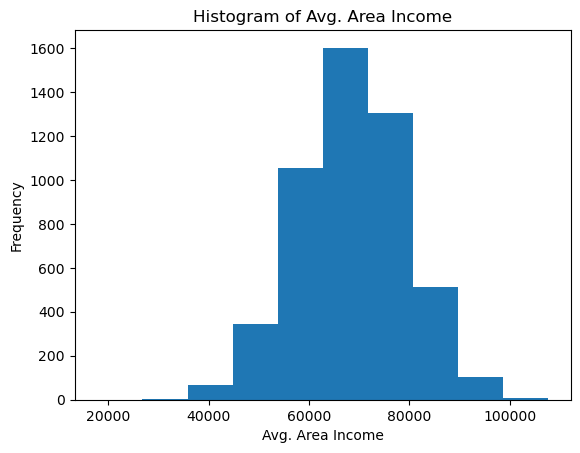

In [7]:
plt.hist(housing["Avg. Area Income"])
plt.title("Histogram of Avg. Area Income")
plt.xlabel("Avg. Area Income")
plt.ylabel("Frequency")




Text(0, 0.5, 'Price')

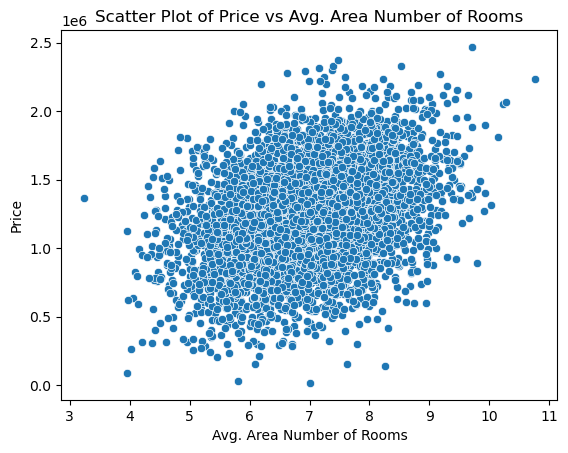

In [10]:
# Visualization 3
sns.scatterplot(data=housing,x="Avg. Area Number of Rooms",y="Price")
plt.title("Scatter Plot of Price vs Avg. Area Number of Rooms")
plt.xlabel("Avg. Area Number of Rooms")
plt.ylabel("Price")




New method! We want to see the correlation between all the variables for our linear regression. This is important because if we use a variable to predict another but they are not very correlated we could get too many variables in the model that aren't very helpful. While this could slightly raise the accuracy of the model on our specific data, the drawback is a reliance on an ineffective variable which could screw up our modeling on different data.

Additionally, for multiple linear regression, we don't want to choose two predictor variables that are highly correlated because this could lead to multicollinearity. This also makes our inferences less reliable because you can't independently change the value of one variable at a time.

In [11]:
numeric_correlations = housing.corr(numeric_only = True)
numeric_correlations

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


Of course, each variable has a correlation of 1 with itself. The numbers are a bit hard to read here, so let's visualize it using a heatmap.

<Axes: >

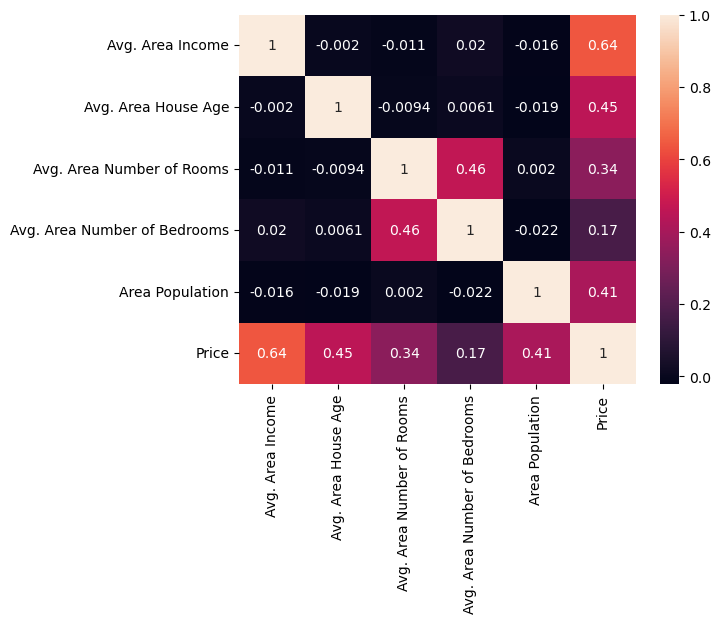

In [12]:
sns.heatmap(numeric_correlations,annot=True)

Quick check: Do you understand what this heatmap is showing us? What predictive variables would be useful here?

# Test/Training and Simple Linear Regression

First, let's try to create a simple linear regression for predicting price. We will use the variable Avg. Area Income because it has the highest correlation to price in this data.

Predictive variable(s):

In [13]:
# For our simple Linear Regression, we pick one variable
# If you want to do a Multiple Linear Regression, you would
# want to pick multiple columns as your features!

X = housing[['Avg. Area Income']]

Predicted variable:

In [14]:
y = housing['Price']

In [21]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 19.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [22]:
from sklearn.model_selection import train_test_split

The code below splits the data into 60% training data (which we will use to train our linear regression on) and 40% testing data (to verify how accurate our predictive modeling is). Other common splits include 70% training 30% testing and 80% training 20% testing. Random state is either used for reproducibility reasons or for pure randomization.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.4, random_state=101)

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
lm = LinearRegression() # lm is now a linear regression model waiting for data to be trained on
lm.fit(X_train,  y_train) # we give the linear regression the data to train and be fitted to.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Now let's get the intercept and coefficient of each variable (which in this case is the slope) when applying our fitted model to our testing data. Make sure you understand why we're using the test data here, and if you don't ask questions!

In [26]:
r_sq = lm.score(X_test, y_test)
print(f"intercept: {lm.intercept_}")
print(f"slope: {lm.coef_}")

intercept: -210001.18740504608
slope: [21.02719844]


Using our fitted linear regression model, let's get the predicted values for our test values.

In [27]:
y_pred = lm.predict(X_test)
y_pred

array([1194089.90073163, 1097565.46216995, 1338505.99242032, ...,
        814778.76866139, 1158482.1954199 , 1177156.93371679],
      shape=(2000,))

For clarity sake, let's make a table with a column of the actual y-values given x-values in our testing data, our predicted y-values, and the residuals (y - predicted y).

In [28]:
model_values = pd.DataFrame({'Actual Values': y_test, 'Predicted Values': y_pred})
model_values['Residuals'] = model_values['Actual Values'] - model_values['Predicted Values']
model_values

,Actual Values,Predicted Values,Residuals
1718,1.251689e+06,1.194090e+06,57598.714971
2511,8.730483e+05,1.097565e+06,-224517.142528
345,1.696978e+06,1.338506e+06,358471.670412
2521,1.063964e+06,1.091773e+06,-27808.224497
54,9.487883e+05,1.323780e+06,-374991.271194
...,...,...,...
1776,1.489520e+06,1.160405e+06,329114.541287
4269,7.777336e+05,6.935304e+05,84203.245713
1661,1.515271e+05,8.147788e+05,-663251.686035
2410,1.343824e+06,1.158482e+06,185342.019724


How do these values look in practice? Are our predictions somewhat accurate? Plot our actual values vs our predicted values to see.

Text(0, 0.5, 'Predicted Values')

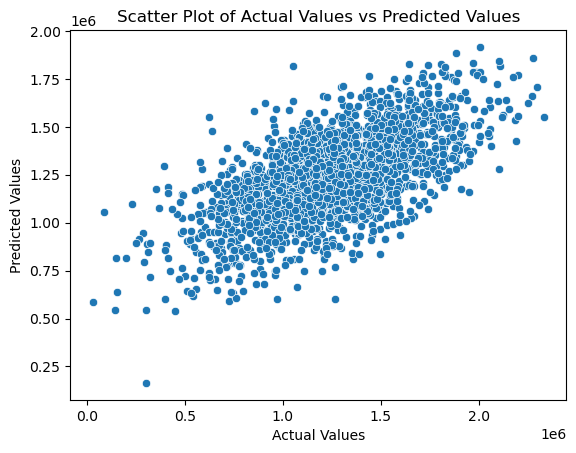

In [29]:
# TO DO
sns.scatterplot(data=model_values,x="Actual Values",y="Predicted Values")
plt.title("Scatter Plot of Actual Values vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")



Is a linear regression model appropriate for the data? Use a residual plot (predicted values vs residuals) to decide.

Text(0, 0.5, 'Residuals')

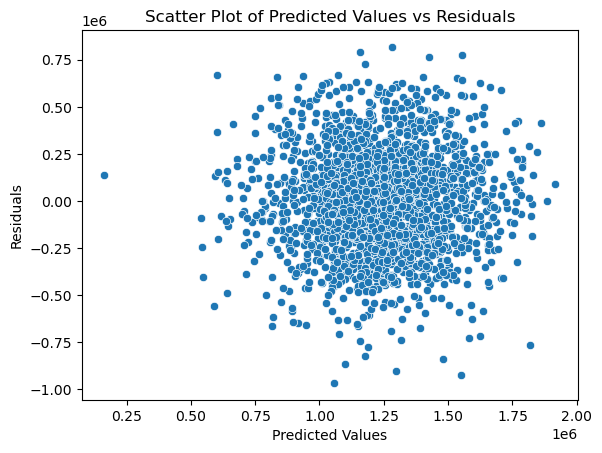

In [30]:
# TO DO
sns.scatterplot(data=model_values,x="Predicted Values",y="Residuals")
plt.title("Scatter Plot of Predicted Values vs Residuals")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")




Let's check the distribution of the residuals (normal distribution is a good sign). Make a histogram of the residuals.

Text(0, 0.5, 'Frequency')

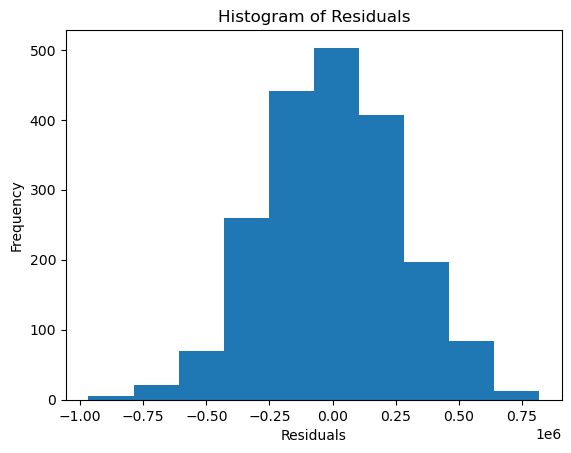

In [31]:
# TO DO
plt.hist(model_values["Residuals"])
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")




## Now let's look into some metrics!

In [32]:
from sklearn import metrics

The MAE (mean absolute error) is the equivalent of our L1 Loss, or Absolute Loss.

In [33]:
metrics.mean_absolute_error(y_test, y_pred)

217170.52745856807

The MSE (mean squared error) is the equivalent of our L2 Loss, or Squared Loss.

In [34]:
metrics.mean_squared_error(y_test, y_pred)

73727682715.874

The RMSE (root mean squared error) is another metric for loss making it more readable.

In [35]:
np.sqrt(metrics.mean_squared_error(y_test, y_pred))

np.float64(271528.41972043)

Which loss function do we use? Using all of them in conjunction helps us get a better understanding of our data: if MAE < RMSE, there are likely to be more outlier-like points in our data since MSE punishes larger errors and the MAE is just the average errors. Same goes for the other way around.

Now let's use statsmodels to get the result. This is a slightly more advanced modeling technique that displays information that may seem more complicated, but can be helpful if you want specific results.

In [37]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 23.6 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [38]:
import statsmodels.api as sm

model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
predictions = model.predict(sm.add_constant(X_test))

print_model = model.summary()
print(print_model)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     2013.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:06:28   Log-Likelihood:                -41790.
No. Observations:                3000   AIC:                         8.358e+04
Df Residuals:                    2998   BIC:                         8.360e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -2.1e+05   3.24e+04  

Seems like our error is somewhat large, can we make it any smaller? Try it yourself using more variables in a multiple linear regression!

# Multiple Linear Regression (DIY)

Let's start by creating a DataFrame with new features...

In [46]:
# TO DO
X = housing[['Avg. Area Income', 'Area Population', 'Avg. Area Number of Rooms']]

And a Series for the variable we want to predict.

In [47]:
# TO DO
y = housing['Price']

Split x and y into test and training sets. The helps us avoid what potential issue?

In [48]:
# TO DO
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=101)

Finally, let's add an intercept. Why is this is important?

In [49]:
# TO DO
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

Now we can fit our model and predict!

In [50]:
# TO DO
model = sm.OLS(y_train, X_train_sm).fit()
predictions = model.predict(X_test_sm)

What kind of information did this regression give us?

In [52]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     3044.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:11:34   Log-Likelihood:                -50907.
No. Observations:                3750   AIC:                         1.018e+05
Df Residuals:                    3746   BIC:                         1.018e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Describe what you observe in a sentence or two.

We can see that the model explains about 71% of the differences in housing price, which makes us think that there is a strong relationship between the predictors and the price. We can see that Average Income, Area Population, and numbr of rooms all increase the price of the house as shown by positive coefficients and small p values

How might we evaluate this model's performance?

In [54]:
# TO DO
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error (MSE): {mse:.2f}")

Mean Squared Error (MSE): 40107757182.16
